Khai báo thư viện


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import time
import copy
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np
from PIL import Image
from google.colab import drive
import os

Kết nối Drive

In [2]:
drive.mount('/content/drive')
!unzip -q "/content/drive/MyDrive/dataset_final.zip" -d "/content/dataset"
data_dir = '/content/dataset/dataset_final'

Mounted at /content/drive


Dataloader

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224, scale=(0.7, 1.0)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(20),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x), data_transforms[x]) for x in ['train', 'val']}
dataloaders = {x: DataLoader(image_datasets[x], batch_size=32, shuffle=True, num_workers=2) for x in ['train', 'val']}
dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val']}
class_names = image_datasets['train'].classes

Tạo kiến trúc MobileNetV2

In [4]:
class SEBlock(nn.Module):
    def __init__(self, channel, reduction=16):
        super(SEBlock, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channel, channel // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channel // reduction, channel, bias=False),
            nn.Sigmoid()
        )
    def forward(self, x):
        b, c, _, _ = x.size()
        y = self.avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1, 1)
        return x * y.expand_as(x)

class InvertedResidualSE(nn.Module):
    def __init__(self, inp, oup, stride, expand_ratio):
        super(InvertedResidualSE, self).__init__()
        hidden_dim = int(round(inp * expand_ratio))
        self.use_res_connect = stride == 1 and inp == oup
        layers = []
        if expand_ratio != 1:
            layers.append(nn.Conv2d(inp, hidden_dim, 1, 1, 0, bias=False))
            layers.append(nn.BatchNorm2d(hidden_dim)); layers.append(nn.ReLU6(inplace=True))
        layers.extend([
            nn.Conv2d(hidden_dim, hidden_dim, 3, stride, 1, groups=hidden_dim, bias=False),
            nn.BatchNorm2d(hidden_dim), nn.ReLU6(inplace=True),
            SEBlock(hidden_dim),
            nn.Conv2d(hidden_dim, oup, 1, 1, 0, bias=False),
            nn.BatchNorm2d(oup),
        ])
        self.conv = nn.Sequential(*layers)
    def forward(self, x):
        return x + self.conv(x) if self.use_res_connect else self.conv(x)

class MobileNetV2_DeepSE(nn.Module):
    def __init__(self, num_classes=10):
        super(MobileNetV2_DeepSE, self).__init__()

        self.configs = [
            [1, 16, 1, 1],
            [6, 24, 3, 2],
            [6, 32, 4, 2],
            [6, 64, 6, 2],
            [6, 96, 4, 1],
            [6, 160, 4, 2],
            [6, 320, 1, 1],
        ]
        input_channel, last_channel = 32, 1280
        features = [nn.Conv2d(3, input_channel, 3, 2, 1, bias=False), nn.BatchNorm2d(input_channel), nn.ReLU6(inplace=True)]
        for t, c, n, s in self.configs:
            for i in range(n):
                stride = s if i == 0 else 1
                features.append(InvertedResidualSE(input_channel, c, stride, expand_ratio=t))
                input_channel = c
        features.append(nn.Conv2d(input_channel, last_channel, 1, 1, 0, bias=False))
        features.append(nn.BatchNorm2d(last_channel)); features.append(nn.ReLU6(inplace=True))
        self.features = nn.Sequential(*features)

        self.classifier = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(last_channel, num_classes))

        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out')

                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01)

                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.features(x)
        x = x.mean([2, 3])
        return self.classifier(x)

Train

In [5]:
model = MobileNetV2_DeepSE(num_classes=len(class_names)).to(device)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(model.parameters(), lr=0.0005, weight_decay=1e-3)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=40)

def train_model_advanced(model, criterion, optimizer, scheduler, num_epochs=30):
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0
    history = {'train_acc': [], 'val_acc': [], 'train_loss': [], 'val_loss': []}

    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        for phase in ['train', 'val']:
            if phase == 'train': model.train()
            else: model.eval()
            running_loss, running_corrects = 0.0, 0

            for inputs, labels in dataloaders[phase]:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs); _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)
                    if phase == 'train':
                        loss.backward()
                        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            if phase == 'train': scheduler.step()

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]
            history[f'{phase}_loss'].append(epoch_loss)
            history[f'{phase}_acc'].append(epoch_acc.item())
            print(f'{phase.capitalize()} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())
                torch.save(model.state_dict(), '/content/drive/MyDrive/best_deep_se_model.pth')

    model.load_state_dict(best_model_wts)
    return model, history

model, history = train_model_advanced(model, criterion, optimizer, scheduler, num_epochs=30)

Epoch 1/30
Train Loss: 2.1223 Acc: 0.2815
Val Loss: 2.0322 Acc: 0.3661
Epoch 2/30
Train Loss: 1.9273 Acc: 0.3743
Val Loss: 1.8659 Acc: 0.4132
Epoch 3/30
Train Loss: 1.7934 Acc: 0.4346
Val Loss: 1.9756 Acc: 0.3971
Epoch 4/30
Train Loss: 1.6875 Acc: 0.4795
Val Loss: 1.6746 Acc: 0.4949
Epoch 5/30
Train Loss: 1.6055 Acc: 0.5237
Val Loss: 1.6271 Acc: 0.5110
Epoch 6/30
Train Loss: 1.5324 Acc: 0.5496
Val Loss: 1.5244 Acc: 0.5522
Epoch 7/30
Train Loss: 1.4648 Acc: 0.5783
Val Loss: 1.4550 Acc: 0.5826
Epoch 8/30
Train Loss: 1.4075 Acc: 0.6069
Val Loss: 1.4804 Acc: 0.5790
Epoch 9/30
Train Loss: 1.3416 Acc: 0.6355
Val Loss: 1.3390 Acc: 0.6333
Epoch 10/30
Train Loss: 1.2953 Acc: 0.6580
Val Loss: 1.3665 Acc: 0.6225
Epoch 11/30
Train Loss: 1.2430 Acc: 0.6831
Val Loss: 1.2280 Acc: 0.6899
Epoch 12/30
Train Loss: 1.1986 Acc: 0.7068
Val Loss: 1.2014 Acc: 0.6983
Epoch 13/30
Train Loss: 1.1577 Acc: 0.7275
Val Loss: 1.1194 Acc: 0.7400
Epoch 14/30
Train Loss: 1.1227 Acc: 0.7358
Val Loss: 1.1344 Acc: 0.7448
E

Danh gia

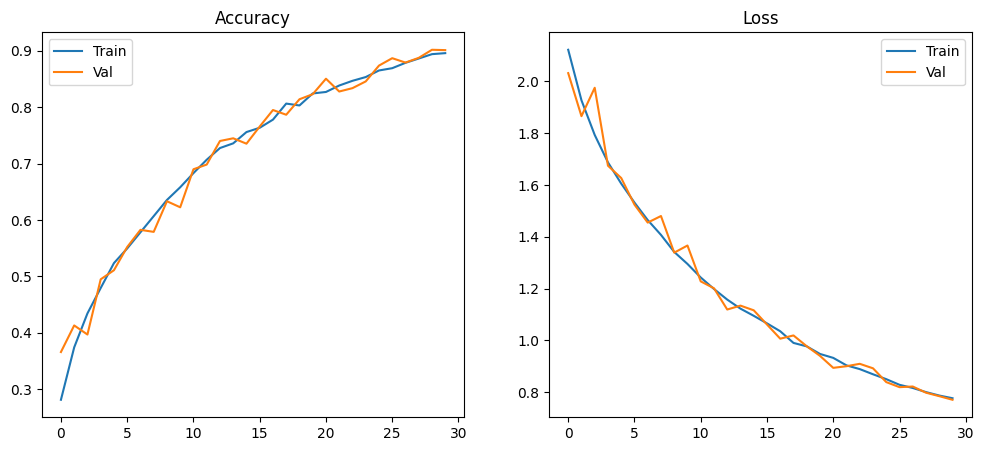

In [6]:
# 1. Vẽ sơ đồ Accuracy và Loss
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1); plt.plot(history['train_acc'], label='Train'); plt.plot(history['val_acc'], label='Val'); plt.title('Accuracy'); plt.legend()
plt.subplot(1, 2, 2); plt.plot(history['train_loss'], label='Train'); plt.plot(history['val_loss'], label='Val'); plt.title('Loss'); plt.legend()
plt.show()


Ma trận nhầm lẫn

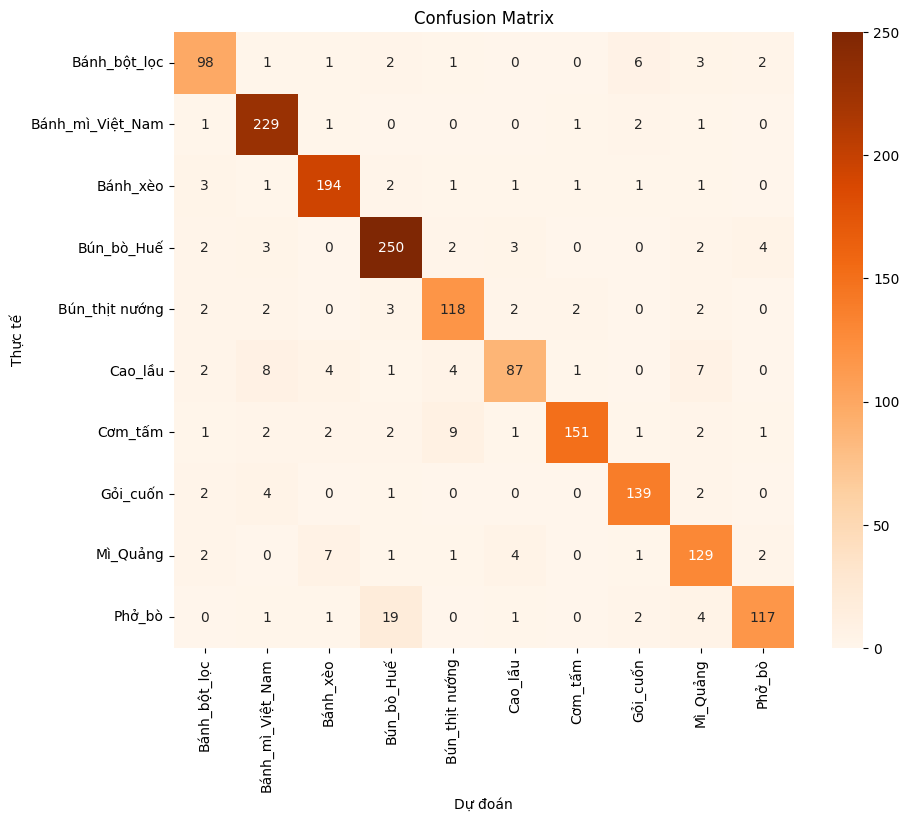

In [7]:
def plot_confusion_matrix(model, dataloader):
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for inputs, labels in dataloader:
            outputs = model(inputs.to(device))
            _, preds = torch.max(outputs, 1)
            y_true.extend(labels.numpy()); y_pred.extend(preds.cpu().numpy())
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Dự đoán'); plt.ylabel('Thực tế'); plt.title('Confusion Matrix'); plt.show()

plot_confusion_matrix(model, dataloaders['val'])

Test time augmentation

In [9]:
def evaluate_with_tta(model, dataloader):
    model.eval()
    corrects = 0
    total = 0


    tta_transforms = [
        lambda x: x,
        lambda x: torch.flip(x, [3]),
        lambda x: transforms.functional.rotate(x, 10),
    ]

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            batch_outputs = []
            for t in tta_transforms:
                aug_inputs = t(inputs)
                outputs = torch.softmax(model(aug_inputs), dim=1)
                batch_outputs.append(outputs)


            final_outputs = torch.mean(torch.stack(batch_outputs), dim=0)
            _, preds = torch.max(final_outputs, 1)
            corrects += torch.sum(preds == labels.data)
            total += labels.size(0)

    print(f'Accuracy với TTA: {corrects.double() / total:.4f}')

evaluate_with_tta(model, dataloaders['val'])

Accuracy với TTA: 0.9064
